In [ ]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Optional, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# Config
# =========================================================
ROOT_DIR = Path(r"D:\mmwave-heart-rate-monitoring-demo")
DATA_DIR = ROOT_DIR / "data"
OUT_DIR = ROOT_DIR / "results" / "alignment"

COND_NAMES = [
    "AWR_steady",
    "AWR_unsteady",
    # "IWR_steady",
    # "IWR_unsteady",
]

HR_MIN_BPM = 40.0
HR_MAX_BPM = 180.0
ZERO_PAD_FACTOR = 8

In [ ]:
# =========================================================
# Helpers
# =========================================================
def sample_key(p: Path) -> int:
    m = re.search(r"sample_(\d+)", p.name)
    return int(m.group(1)) if m else 10**9


def find_waveform_csv(sample_dir: Path) -> Optional[Path]:
    cand = sample_dir / "waveform.csv"
    if cand.exists():
        return cand

    hits = list(sample_dir.glob("*waveform*.csv"))
    if hits:
        return hits[0]

    return None


def load_waveform(csv_path: Path) -> Tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(csv_path, comment="#")

    cols_lower = {c.lower(): c for c in df.columns}
    if "time" not in cols_lower:
        raise ValueError(f"{csv_path} 缺少 time 欄位")
    if "lsb" not in cols_lower:
        raise ValueError(f"{csv_path} 缺少 LSB 欄位")

    time_col = cols_lower["time"]
    sig_col = cols_lower["lsb"]

    t = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)
    x = pd.to_numeric(df[sig_col], errors="coerce").to_numpy(dtype=float)

    mask = np.isfinite(t) & np.isfinite(x)
    t = t[mask]
    x = x[mask]

    if len(t) < 8:
        raise ValueError(f"{csv_path} 有效資料太少，無法做 FFT")

    return t, x


def estimate_fs(t: np.ndarray) -> float:
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if len(dt) == 0:
        raise ValueError("time 欄位無法估計取樣率")
    return 1.0 / np.median(dt)


def compute_fft_spectrum(
    t: np.ndarray,
    x: np.ndarray,
    zero_pad_factor: int = 8,
) -> Tuple[float, np.ndarray, np.ndarray]:
    fs = estimate_fs(t)

    n = len(x)
    n_fft = int(2 ** np.ceil(np.log2(n * zero_pad_factor)))

    spec = np.fft.rfft(x, n=n_fft)
    freqs_hz = np.fft.rfftfreq(n_fft, d=1.0 / fs)
    power = np.abs(spec) ** 2

    return fs, freqs_hz, power


def estimate_hr_from_band(
    freqs_hz: np.ndarray,
    power: np.ndarray,
    hr_min_bpm: float = 40.0,
    hr_max_bpm: float = 180.0,
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    fmin = hr_min_bpm / 60.0
    fmax = hr_max_bpm / 60.0

    band_mask = (freqs_hz >= fmin) & (freqs_hz <= fmax)
    freqs_band = freqs_hz[band_mask]
    power_band = power[band_mask]

    if len(freqs_band) == 0:
        raise ValueError("HR 搜尋頻帶內沒有頻率點")

    peak_idx = int(np.argmax(power_band))
    peak_freq_hz = float(freqs_band[peak_idx])
    hr_bpm = peak_freq_hz * 60.0

    return freqs_band, power_band, peak_freq_hz, hr_bpm


def estimate_hr_fft_from_csv(
    csv_path: Path,
    hr_min_bpm: float = HR_MIN_BPM,
    hr_max_bpm: float = HR_MAX_BPM,
    zero_pad_factor: int = ZERO_PAD_FACTOR,
) -> float:
    t, x = load_waveform(csv_path)
    _, freqs_hz, power = compute_fft_spectrum(
        t, x, zero_pad_factor=zero_pad_factor
    )
    _, _, _, hr_bpm = estimate_hr_from_band(
        freqs_hz, power,
        hr_min_bpm=hr_min_bpm,
        hr_max_bpm=hr_max_bpm
    )
    return float(hr_bpm)


def process_condition(cond_dir: Path, out_csv: Path) -> pd.DataFrame:
    sample_dirs = [
        p for p in cond_dir.iterdir()
        if p.is_dir() and re.fullmatch(r"sample_\d+", p.name)
    ]
    sample_dirs = sorted(sample_dirs, key=sample_key)

    rows: List[dict] = []

    for sdir in sample_dirs:
        wf_csv = find_waveform_csv(sdir)

        if wf_csv is None:
            hr = np.nan
            print(f"[WARN] 找不到 waveform.csv: {sdir}")
        else:
            try:
                hr = estimate_hr_fft_from_csv(wf_csv)
            except Exception as e:
                print(f"[WARN] {wf_csv}: {e}")
                hr = np.nan

        rows.append({
            "sample_name": sdir.name,
            "mmw_HR_raw": hr
        })

    df_out = pd.DataFrame(rows, columns=["sample_name", "mmw_HR_raw"])
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df_out.to_csv(out_csv, index=False, encoding="utf-8-sig")
    return df_out


def batch_process_all_conditions(
    data_dir: Path,
    cond_names: List[str],
    out_dir: Path,
) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)

    for cond in cond_names:
        cond_dir = data_dir / cond
        out_csv = out_dir / f"{cond}.csv"

        if not cond_dir.exists():
            print(f"[SKIP] 找不到資料夾: {cond_dir}")
            continue

        df_out = process_condition(cond_dir, out_csv)
        print(f"[OK] {cond}: {len(df_out)} 筆 -> {out_csv}")


def demo_plot_fft_hr_band(
    waveform_csv: Path,
    hr_min_bpm: float = HR_MIN_BPM,
    hr_max_bpm: float = HR_MAX_BPM,
    zero_pad_factor: int = ZERO_PAD_FACTOR,
) -> None:
    t, x = load_waveform(waveform_csv)
    fs, freqs_hz, power = compute_fft_spectrum(
        t, x, zero_pad_factor=zero_pad_factor
    )
    freqs_band, power_band, _, hr_bpm = estimate_hr_from_band(
        freqs_hz, power,
        hr_min_bpm=hr_min_bpm,
        hr_max_bpm=hr_max_bpm
    )

    peak_idx = int(np.argmax(power_band))
    peak_power = float(power_band[peak_idx])

    plt.figure(figsize=(8, 5))
    plt.plot(freqs_band * 60.0, power_band, linewidth=1.5, label="HR band spectrum")
    plt.axvline(hr_bpm, linestyle="--", linewidth=1.2, label=f"Peak = {hr_bpm:.2f} bpm")
    plt.scatter([hr_bpm], [peak_power], s=50)
    plt.xlabel("Heart rate (bpm)")
    plt.ylabel("Power")
    plt.title(f"{waveform_csv.parent.parent.name} / {waveform_csv.parent.name}\nZoomed HR search band")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"[DEMO] file = {waveform_csv}")
    print(f"[DEMO] Estimated fs = {fs:.6f} Hz")
    print(f"[DEMO] Estimated HR = {hr_bpm:.2f} bpm")

[OK] AWR_steady: 50 筆 -> D:\mmwave-heart-rate-monitoring-demo\data\mmwave-heart-rate-dataset\results\alignment\AWR_steady.csv
[OK] AWR_unsteady: 80 筆 -> D:\mmwave-heart-rate-monitoring-demo\data\mmwave-heart-rate-dataset\results\alignment\AWR_unsteady.csv


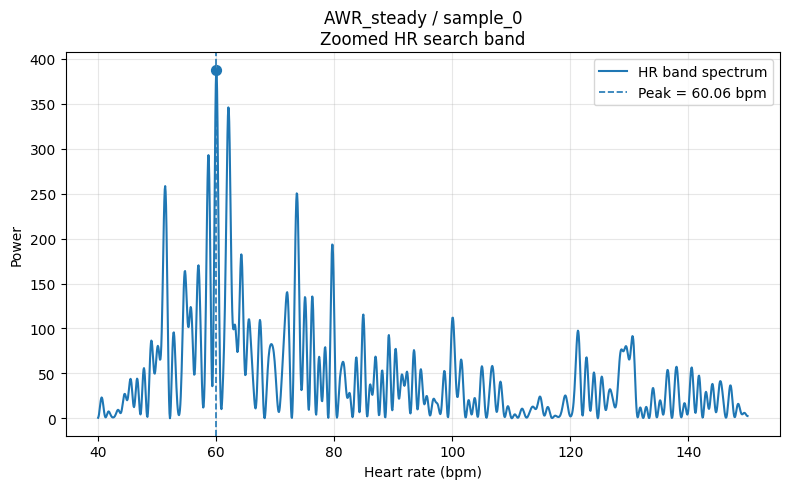

[DEMO] file = D:\mmwave-heart-rate-monitoring-demo\data\mmwave-heart-rate-dataset\AWR_steady\sample_0\mmWave_waveform.csv
[DEMO] Estimated fs = 5.000000 Hz
[DEMO] Estimated HR = 60.06 bpm


In [12]:
if __name__ == "__main__":
    # -------------------------
    # 1) 批次處理四個 condition
    # -------------------------
    batch_process_all_conditions(
        data_dir=DATA_DIR,
        cond_names=COND_NAMES,
        out_dir=OUT_DIR,
    )
    # -------------------------
    # 2) demo：每個 condition 抓一筆 sample_0，兩張圖合成一張
    #    輸出到 D:\mmwave-heart-rate-monitoring-demo\results\alignment\四個資料夾
    # -------------------------
    demo_sample = "sample_0"

    for cond in COND_NAMES[0:1]:
        demo_sample_dir = DATA_DIR / cond / demo_sample
        demo_csv = find_waveform_csv(demo_sample_dir)

        if demo_csv is None:
            print(f"[DEMO-SKIP] 找不到 demo waveform.csv: {demo_sample_dir}")
            continue

        demo_plot_fft_hr_band(
            waveform_csv=demo_csv,
        )
